<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [113]:
#Importation de la librairie Pandas
import pandas as pd
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 



<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [144]:
#Importation du fichier population.csv
sn = pd.read_csv("C:/Users/User/Desktop/Projet 4/sous_nutrition.csv", encoding="utf-8", sep=",")

#Importation du fichier dispo_alimentaire.csv
da = pd.read_csv("C:/Users/User/Desktop/Projet 4/dispo_alimentaire.csv", encoding="utf-8", sep=",")

#Importation du fichier aide_alimentaire.csv
pop = pd.read_csv("C:/Users/User/Desktop/Projet 4/population.csv", encoding="utf-8", sep=",")

#Importation du fichier sous_nutrition.csv
al = pd.read_csv("C:/Users/User/Desktop/Projet 4/aide_alimentaire.csv", encoding="utf-8", sep=",")

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [145]:
#Afficher les dimensions du dataset

def dimension_donnees(tableau_dim, nom_tableau_dim):
    print(f"Le tableau '{nom_tableau_dim}' comporte {tableau_dim.shape[0]} observation(s) ou article(s).")
    print(f"Le tableau '{nom_tableau_dim}' comporte {tableau_dim.shape[1]} colonne(s).")

dimension_donnees(pop, "Population")

Le tableau 'Population' comporte 1416 observation(s) ou article(s).
Le tableau 'Population' comporte 3 colonne(s).


In [146]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes

def explorer_données(tableau, nom_tableau):
    print(f"\n=== Exploration des données : {nom_tableau} ===")
    print("Nombre de colonnes :", len(tableau.columns))
    print("\nTypes de données :\n", tableau.dtypes)
    print("\nNombre de valeurs par colonne :\n", tableau.count())

explorer_données(pop, "Population")



=== Exploration des données : Population ===
Nombre de colonnes : 3

Types de données :
 Zone       object
Année       int64
Valeur    float64
dtype: object

Nombre de valeurs par colonne :
 Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [147]:
#Affichage les 5 premières lignes de la table
def Première_ligne_5(tableau_cinq, nom_tableau_cinq):
    print(f"5 Premières ligne: {nom_tableau_cinq} ===")
    print(tableau_cinq.head(5))
    
Première_ligne_5(pop, "Population")

    

5 Premières ligne: Population ===
          Zone  Année     Valeur
0  Afghanistan   2013  32269.589
1  Afghanistan   2014  33370.794
2  Afghanistan   2015  34413.603
3  Afghanistan   2016  35383.032
4  Afghanistan   2017  36296.113


In [148]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
pop["Valeur"] = pd.to_numeric(pop["Valeur"])
pop["Population_multiple"] = pop["Valeur"] * 1000

print(pop)

             Zone  Année     Valeur  Population_multiple
0     Afghanistan   2013  32269.589           32269589.0
1     Afghanistan   2014  33370.794           33370794.0
2     Afghanistan   2015  34413.603           34413603.0
3     Afghanistan   2016  35383.032           35383032.0
4     Afghanistan   2017  36296.113           36296113.0
...           ...    ...        ...                  ...
1411     Zimbabwe   2014  13586.707           13586707.0
1412     Zimbabwe   2015  13814.629           13814629.0
1413     Zimbabwe   2016  14030.331           14030331.0
1414     Zimbabwe   2017  14236.595           14236595.0
1415     Zimbabwe   2018  14438.802           14438802.0

[1416 rows x 4 columns]


In [149]:
#changement du nom de la colonne Valeur par Population

pop.rename(columns={'Valeur': 'Population'}, inplace=True)


In [150]:
#Affichage les 5 premières lignes de la table pour voir les modifications
Première_ligne_5(pop, "Population")

5 Premières ligne: Population ===
          Zone  Année  Population  Population_multiple
0  Afghanistan   2013   32269.589           32269589.0
1  Afghanistan   2014   33370.794           33370794.0
2  Afghanistan   2015   34413.603           34413603.0
3  Afghanistan   2016   35383.032           35383032.0
4  Afghanistan   2017   36296.113           36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [151]:
#Afficher les dimensions du dataset
dimension_donnees(da, "Disponibilité alimentaire")

Le tableau 'Disponibilité alimentaire' comporte 15605 observation(s) ou article(s).
Le tableau 'Disponibilité alimentaire' comporte 18 colonne(s).


In [152]:
#Consulter le nombre de colonnes
explorer_données(da, "Disponibilité alimentaire")


=== Exploration des données : Disponibilité alimentaire ===
Nombre de colonnes : 18

Types de données :
 Zone                                                              object
Produit                                                           object
Origine                                                           object
Aliments pour animaux                                            float64
Autres Utilisations                                              float64
Disponibilité alimentaire (Kcal/personne/jour)                   float64
Disponibilité alimentaire en quantité (kg/personne/an)           float64
Disponibilité de matière grasse en quantité (g/personne/jour)    float64
Disponibilité de protéines en quantité (g/personne/jour)         float64
Disponibilité intérieure                                         float64
Exportations - Quantité                                          float64
Importations - Quantité                                          float64
Nourriture        

In [153]:
#Affichage les 5 premières lignes de la table
Première_ligne_5(da, "Disponibilité alimentaire")

5 Premières ligne: Disponibilité alimentaire ===
          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    NaN   
1  Afghanistan        Agrumes, Autres  vegetale                    NaN   
2  Afghanistan  Aliments pour enfants  vegetale                    NaN   
3  Afghanistan                 Ananas  vegetale                    NaN   
4  Afghanistan                Bananes  vegetale                    NaN   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  NaN                                             5.0   
1                  NaN                                             1.0   
2                  NaN                                             1.0   
3                  NaN                                             0.0   
4                  NaN                                             4.0   

   Disponibilité alimentaire en quantité (kg/personne/an)  \


In [154]:
#remplacement des NaN dans le dataset par des 0
da.replace(np.nan, 0, inplace=True)

Première_ligne_5(da, "Disponibilité alimentaire")


5 Premières ligne: Disponibilité alimentaire ===
          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    0.0   
1  Afghanistan        Agrumes, Autres  vegetale                    0.0   
2  Afghanistan  Aliments pour enfants  vegetale                    0.0   
3  Afghanistan                 Ananas  vegetale                    0.0   
4  Afghanistan                Bananes  vegetale                    0.0   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  0.0                                             5.0   
1                  0.0                                             1.0   
2                  0.0                                             1.0   
3                  0.0                                             0.0   
4                  0.0                                             4.0   

   Disponibilité alimentaire en quantité (kg/personne/an)  \


In [155]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg


In [156]:
#Affichage les 5 premières lignes de la table
Première_ligne_5(da, "Disponibilité alimentaire")


5 Premières ligne: Disponibilité alimentaire ===
          Zone                Produit   Origine  Aliments pour animaux  \
0  Afghanistan       Abats Comestible   animale                    0.0   
1  Afghanistan        Agrumes, Autres  vegetale                    0.0   
2  Afghanistan  Aliments pour enfants  vegetale                    0.0   
3  Afghanistan                 Ananas  vegetale                    0.0   
4  Afghanistan                Bananes  vegetale                    0.0   

   Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour)  \
0                  0.0                                             5.0   
1                  0.0                                             1.0   
2                  0.0                                             1.0   
3                  0.0                                             0.0   
4                  0.0                                             4.0   

   Disponibilité alimentaire en quantité (kg/personne/an)  \


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [157]:
#Afficher les dimensions du dataset
dimension_donnees(al, "Aide alimentaire")

Le tableau 'Aide alimentaire' comporte 1475 observation(s) ou article(s).
Le tableau 'Aide alimentaire' comporte 4 colonne(s).


In [158]:
#Consulter le nombre de colonnes
explorer_données(al, "Aide alimentaire")


=== Exploration des données : Aide alimentaire ===
Nombre de colonnes : 4

Types de données :
 Pays bénéficiaire    object
Année                 int64
Produit              object
Valeur                int64
dtype: object

Nombre de valeurs par colonne :
 Pays bénéficiaire    1475
Année                1475
Produit              1475
Valeur               1475
dtype: int64


In [159]:
#Affichage les 5 premières lignes de la table
Première_ligne_5(al, "Aide alimentaire")

5 Premières ligne: Aide alimentaire ===
  Pays bénéficiaire  Année              Produit  Valeur
0       Afghanistan   2013  Autres non-céréales     682
1       Afghanistan   2014  Autres non-céréales     335
2       Afghanistan   2013         Blé et Farin   39224
3       Afghanistan   2014         Blé et Farin   15160
4       Afghanistan   2013             Céréales   40504


In [160]:
#changement du nom de la colonne Pays bénéficiaire par Zone
al.rename(columns={'Pays bénéficiaire': 'Zone'}, inplace=True)

Première_ligne_5(al, "aide")

5 Premières ligne: aide ===
          Zone  Année              Produit  Valeur
0  Afghanistan   2013  Autres non-céréales     682
1  Afghanistan   2014  Autres non-céréales     335
2  Afghanistan   2013         Blé et Farin   39224
3  Afghanistan   2014         Blé et Farin   15160
4  Afghanistan   2013             Céréales   40504


In [161]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
al["Valeur_kg"] = al["Valeur"] * 100

print(al.head())

          Zone  Année              Produit  Valeur  Valeur_kg
0  Afghanistan   2013  Autres non-céréales     682      68200
1  Afghanistan   2014  Autres non-céréales     335      33500
2  Afghanistan   2013         Blé et Farin   39224    3922400
3  Afghanistan   2014         Blé et Farin   15160    1516000
4  Afghanistan   2013             Céréales   40504    4050400


In [162]:
#Affichage les 5 premières lignes de la table
Première_ligne_5(al, "Aide_alimentaire")

5 Premières ligne: Aide_alimentaire ===
          Zone  Année              Produit  Valeur  Valeur_kg
0  Afghanistan   2013  Autres non-céréales     682      68200
1  Afghanistan   2014  Autres non-céréales     335      33500
2  Afghanistan   2013         Blé et Farin   39224    3922400
3  Afghanistan   2014         Blé et Farin   15160    1516000
4  Afghanistan   2013             Céréales   40504    4050400


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [163]:
#Afficher les dimensions du dataset
dimension_donnees(sn, "Sous nutrition")

Le tableau 'Sous nutrition' comporte 1218 observation(s) ou article(s).
Le tableau 'Sous nutrition' comporte 3 colonne(s).


In [164]:
#Consulter le nombre de colonnes
explorer_données(sn, "Sous nutrition")


=== Exploration des données : Sous nutrition ===
Nombre de colonnes : 3

Types de données :
 Zone      object
Année     object
Valeur    object
dtype: object

Nombre de valeurs par colonne :
 Zone      1218
Année     1218
Valeur     624
dtype: int64


In [165]:
#Afficher les 5 premières lignes de la table
Première_ligne_5(sn, "Sous nutrition")

5 Premières ligne: Sous nutrition ===
          Zone      Année Valeur
0  Afghanistan  2012-2014    8.6
1  Afghanistan  2013-2015    8.8
2  Afghanistan  2014-2016    8.9
3  Afghanistan  2015-2017    9.7
4  Afghanistan  2016-2018   10.5


In [168]:
#Puis remplacement des NaN en 0
sn.replace(np.nan, 0, inplace=True)


In [169]:
#changement du nom de la colonne Valeur par sous_nutrition
sn.rename(columns={'Valeur' : 'sous_nutrition'}, inplace=True)


In [170]:
sn["sous_nutrition"] = pd.to_numeric(sn["sous_nutrition"], errors="coerce")

sn["Sous_nutri_multiple"] = sn["sous_nutrition"] * 1_000_000

In [171]:
#Afficher les 5 premières lignes de la table
Première_ligne_5(sn, "Sous nutrition")

5 Premières ligne: Sous nutrition ===
          Zone      Année  sous_nutrition  Sous_nutri_multiple
0  Afghanistan  2012-2014             8.6            8600000.0
1  Afghanistan  2013-2015             8.8            8800000.0
2  Afghanistan  2014-2016             8.9            8900000.0
3  Afghanistan  2015-2017             9.7            9700000.0
4  Afghanistan  2016-2018            10.5           10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [172]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
def contains_année(year_str, target_year):
    year_str = str(year_str).strip()
    
    if '-' in year_str:
        start, end = map(int, year_str.split('-'))

        return start < target_year and end > target_year
    else:
        return int(year_str) == target_year
    
pop_2017 = pop[pop['Année'].apply(lambda x: contains_année(x, 2017))]
sn_2017 = sn[sn['Année'].apply(lambda x: contains_année(x, 2017))]

pop_sn_2017 = pd.merge(sn_2017, pop_2017, on='Zone', how='inner')

print(pop_sn_2017)

                                       Zone    Année_x  sous_nutrition  \
0                               Afghanistan  2016-2018            10.5   
1                            Afrique du Sud  2016-2018             3.1   
2                                   Albanie  2016-2018             0.1   
3                                   Algérie  2016-2018             1.3   
4                                 Allemagne  2016-2018             0.0   
..                                      ...        ...             ...   
198  Venezuela (République bolivarienne du)  2016-2018             8.0   
199                                Viet Nam  2016-2018             6.5   
200                                   Yémen  2016-2018             0.0   
201                                  Zambie  2016-2018             0.0   
202                                Zimbabwe  2016-2018             0.0   

     Sous_nutri_multiple  Année_y  Population  Population_multiple  
0             10500000.0     2017   36296.

In [173]:
#Affichage du dataset
explorer_données(pop_sn_2017, "Population sous nutrition")


=== Exploration des données : Population sous nutrition ===
Nombre de colonnes : 7

Types de données :
 Zone                    object
Année_x                 object
sous_nutrition         float64
Sous_nutri_multiple    float64
Année_y                  int64
Population             float64
Population_multiple    float64
dtype: object

Nombre de valeurs par colonne :
 Zone                   203
Année_x                203
sous_nutrition         183
Sous_nutri_multiple    183
Année_y                203
Population             203
Population_multiple    203
dtype: int64


                                       Zone    Année_x  sous_nutrition  \
0                               Afghanistan  2016-2018            10.5   
1                            Afrique du Sud  2016-2018             3.1   
2                                   Albanie  2016-2018             0.1   
3                                   Algérie  2016-2018             1.3   
4                                 Allemagne  2016-2018             0.0   
..                                      ...        ...             ...   
198  Venezuela (République bolivarienne du)  2016-2018             8.0   
199                                Viet Nam  2016-2018             6.5   
200                                   Yémen  2016-2018             0.0   
201                                  Zambie  2016-2018             0.0   
202                                Zimbabwe  2016-2018             0.0   

     Sous_nutri_multiple  Année_y  Population  Population_multiple  
0             10500000.0     2017   36296.

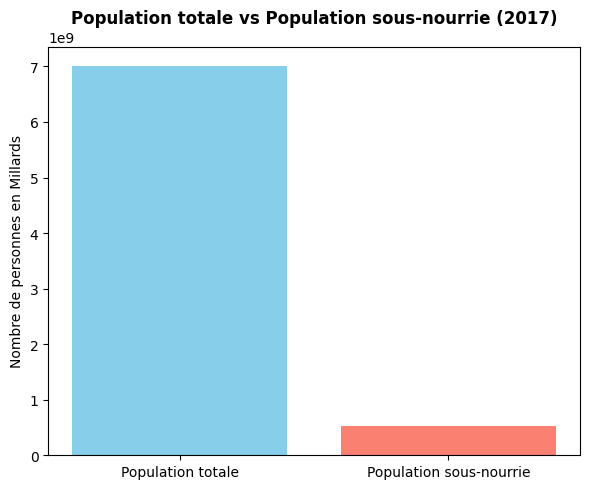

In [174]:

print(pop_sn_2017) 
pop_sn_2017["Population_multiple"] = pd.to_numeric(pop_sn_2017["Population_multiple"], errors="coerce")



pop_totale_2017 = pop_sn_2017["Population_multiple"].sum()
pop_sous_nourrie_2017 = pop_sn_2017["Sous_nutri_multiple"].sum()

# Préparer les données
categories = ["Population totale", "Population sous-nourrie"]
valeurs = [pop_totale_2017 - pop_sous_nourrie_2017 , pop_sous_nourrie_2017]

# Création du graphique
plt.figure(figsize=(6,5))
plt.bar(categories, valeurs, color=["skyblue", "salmon"])
plt.title("Population totale vs Population sous-nourrie (2017)", fontweight='bold')
plt.ylabel("Nombre de personnes en Millards")
plt.tight_layout()


# Calcul du pourcentage global de sous-nutrition
pourcentage_sn = (pop_sous_nourrie_2017 / pop_totale_2017) * 100
print(f"Pourcentage global de population sous-nourrie : {pourcentage_sn:.2f}%")

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [175]:
#2500 Source => https://fr.wikipedia.org/wiki/Ration_alimentaire#:~:text=Selon%20J.,500%20kcal%2Fpersonne%2Fjour.

remplacements = {
    "République populaire démocratique de Corée": "Corée du Nord",
    "République arabe syrienne": "Syrie",
    "République démocratique du Congo": "Congo",
    "République centrafricaine": "Centrafrique",
    "États-Unis d'Amérique": "Amérique"
}

da["Zone"] = da["Zone"].replace(remplacements)
pop["Zone"] = pop["Zone"].replace(remplacements)
al["Zone"] = al["Zone"].replace(remplacements)
sn["Zone"] = sn["Zone"].replace(remplacements)

In [176]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
pop_da = pd.merge(da, pop_2017, on="Zone", how="inner")

print(pop_da)





               Zone                Produit   Origine  Aliments pour animaux  \
0       Afghanistan       Abats Comestible   animale                    0.0   
1       Afghanistan        Agrumes, Autres  vegetale                    0.0   
2       Afghanistan  Aliments pour enfants  vegetale                    0.0   
3       Afghanistan                 Ananas  vegetale                    0.0   
4       Afghanistan                Bananes  vegetale                    0.0   
...             ...                    ...       ...                    ...   
15170  Îles Salomon       Viande de Suides   animale                    0.0   
15171  Îles Salomon    Viande de Volailles   animale                    0.0   
15172  Îles Salomon          Viande, Autre   animale                    0.0   
15173  Îles Salomon                    Vin  vegetale                    0.0   
15174  Îles Salomon         Épices, Autres  vegetale                    0.0   

       Autres Utilisations  Disponibilité alimentai

In [177]:
#Affichage du nouveau dataframe
dimension_donnees(pop_da, "Disponibilité Alimentaire par population")

Le tableau 'Disponibilité Alimentaire par population' comporte 15175 observation(s) ou article(s).
Le tableau 'Disponibilité Alimentaire par population' comporte 21 colonne(s).


In [178]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
pop_da["da_kcal"] = pop_da["Disponibilité alimentaire (Kcal/personne/jour)"] * pop_da["Population_multiple"]

# Moyenne pondérée des Kcal par pays
moy_kcal_pays = (
    pop_da
    .groupby("Zone")["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
)

moy_kcal = moy_kcal_pays.mean()
print(moy_kcal)

print(pop_da)

2846.792899408284
               Zone                Produit   Origine  Aliments pour animaux  \
0       Afghanistan       Abats Comestible   animale                    0.0   
1       Afghanistan        Agrumes, Autres  vegetale                    0.0   
2       Afghanistan  Aliments pour enfants  vegetale                    0.0   
3       Afghanistan                 Ananas  vegetale                    0.0   
4       Afghanistan                Bananes  vegetale                    0.0   
...             ...                    ...       ...                    ...   
15170  Îles Salomon       Viande de Suides   animale                    0.0   
15171  Îles Salomon    Viande de Volailles   animale                    0.0   
15172  Îles Salomon          Viande, Autre   animale                    0.0   
15173  Îles Salomon                    Vin  vegetale                    0.0   
15174  Îles Salomon         Épices, Autres  vegetale                    0.0   

       Autres Utilisations  Dispo

In [179]:



# Calculs
pop_nourrisable = (moy_kcal * pop_totale_2017) / 2500
pop_sn_ca = pop_totale_2017 - pop_nourrisable

print(f"Population nourrissable : {pop_nourrisable:,.0f}")
print(f"Population non nourrie : {pop_sn_ca:,.0f}")



Population nourrissable : 8,590,253,119
Population non nourrie : -1,046,454,340


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [180]:
#Transfert des données avec les végétaux dans un nouveau dataframe

pop_da["da_kcal_veg"] = pop_da.loc[
    pop_da["Origine"] == "vegetale",
    "Disponibilité alimentaire (Kcal/personne/jour)"
]




In [181]:
#Calcul du nombre de kcal disponible pour les végétaux
total_kcal_veg = pop_da["da_kcal_veg"].sum() 

print(total_kcal_veg)

387587.0


2293.414201183432
               Zone                Produit   Origine  Aliments pour animaux  \
0       Afghanistan       Abats Comestible   animale                    0.0   
1       Afghanistan        Agrumes, Autres  vegetale                    0.0   
2       Afghanistan  Aliments pour enfants  vegetale                    0.0   
3       Afghanistan                 Ananas  vegetale                    0.0   
4       Afghanistan                Bananes  vegetale                    0.0   
...             ...                    ...       ...                    ...   
15170  Îles Salomon       Viande de Suides   animale                    0.0   
15171  Îles Salomon    Viande de Volailles   animale                    0.0   
15172  Îles Salomon          Viande, Autre   animale                    0.0   
15173  Îles Salomon                    Vin  vegetale                    0.0   
15174  Îles Salomon         Épices, Autres  vegetale                    0.0   

       Autres Utilisations  Dispo

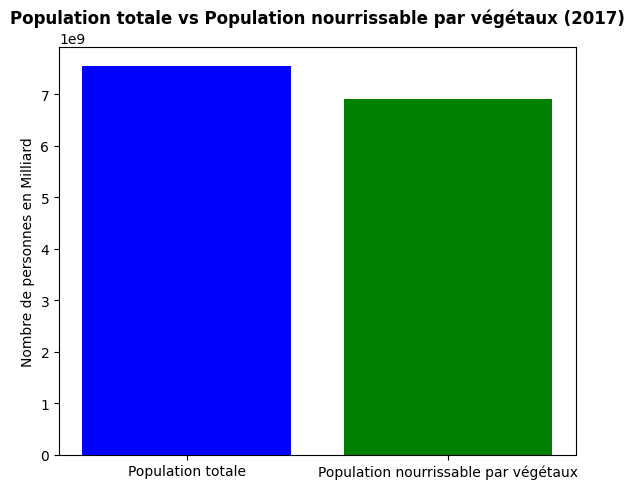

In [182]:

# Moyenne pondérée des Kcal par pays
moy_kcal_pays_veg = (
    pop_da
    .groupby("Zone")["da_kcal_veg"]
    .sum()
)

moy_kcal_veg = moy_kcal_pays_veg.mean()
print(moy_kcal_veg)

print(pop_da)

pop_nourrisable_veg = (moy_kcal_veg * pop_totale_2017) / 2500
# Données pour le graphique
categories_veg = ["Population totale", "Population nourrissable par végétaux"]
valeurs_veg = [pop_totale_2017, pop_nourrisable_veg]

pop_max_veg_pourcentage = (pop_nourrisable_veg /pop_totale_2017) * 100

print(pop_max_veg_pourcentage * pop_totale_2017)


print(pop_max_veg_pourcentage)
plt.figure(figsize=(6,5))
plt.bar(categories_veg, valeurs_veg, color=["blue", "green"])
plt.title("Population totale vs Population nourrissable par végétaux (2017)", fontweight='bold')
plt.ylabel("Nombre de personnes en Milliard")
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

18434905.0


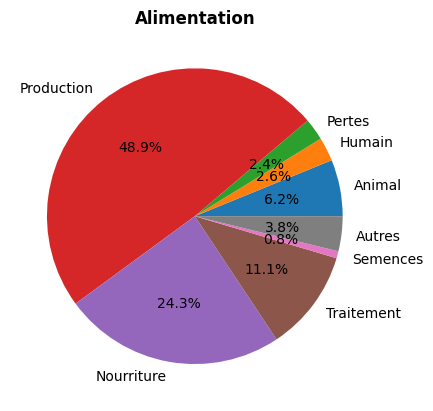

In [183]:
#Calcul de la disponibilité totale
#Calcul toutes les sommes des différents utilisage de la nourriture
da_animal = pop_da["Aliments pour animaux"].sum()
da_humain = pop_da["Disponibilité alimentaire (Kcal/personne/jour)"].sum()
da_perte = pop_da["Pertes"].sum()
da_production =  pop_da["Production"].sum()
da_nourriture  = pop_da["Nourriture"].sum()
da_traitement = pop_da["Traitement"].sum()
da_semences = pop_da["Semences"].sum()
da_autre = pop_da["Autres Utilisations"].sum()

# Calcul de la disponibilité intérieur 
dispo_int = da_animal + da_humain + da_perte + da_production + da_nourriture + da_traitement + da_semences + da_autre
print(dispo_int)


#  Création du Graphique en camembert pour chaque utilisation 
labels = ["Animal", "Humain", "Pertes", "Production","Nourriture", "Traitement", "Semences", "Autres"]
sizes = [da_animal, da_humain, da_perte, da_production, da_nourriture, da_traitement, da_semences, da_autre]


plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Alimentation", fontweight='bold')
plt.show()

In [184]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 

colonnes_aliments = ["Aliments pour animaux", "Pertes", "Nourriture"]

for col in colonnes_aliments:
    print(f"\n📊 Somme par Zone pour la colonne : {col}")
    
    
    da_zone_type = da.groupby('Zone')[col].sum().reset_index()
    
    print(da_zone_type)


📊 Somme par Zone pour la colonne : Aliments pour animaux
                    Zone  Aliments pour animaux
0            Afghanistan                  768.0
1         Afrique du Sud                 5309.0
2                Albanie                  660.0
3                Algérie                 4352.0
4              Allemagne                30209.0
..                   ...                    ...
169               Égypte                15084.0
170  Émirats arabes unis                 1174.0
171             Équateur                 1200.0
172             Éthiopie                  685.0
173         Îles Salomon                    0.0

[174 rows x 2 columns]

📊 Somme par Zone pour la colonne : Pertes
                    Zone  Pertes
0            Afghanistan  1135.0
1         Afrique du Sud  2193.0
2                Albanie   276.0
3                Algérie  3753.0
4              Allemagne  3781.0
..                   ...     ...
169               Égypte  7608.0
170  Émirats arabes unis   705.0
17

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [185]:
#Création d'une liste avec toutes les variables
cereal = ["Blé", "Riz (Eq Blanchi)", "Orge", 'Maïs', "Seigle", "Avoine", "Millet", "Sorgho", "Céréales"]

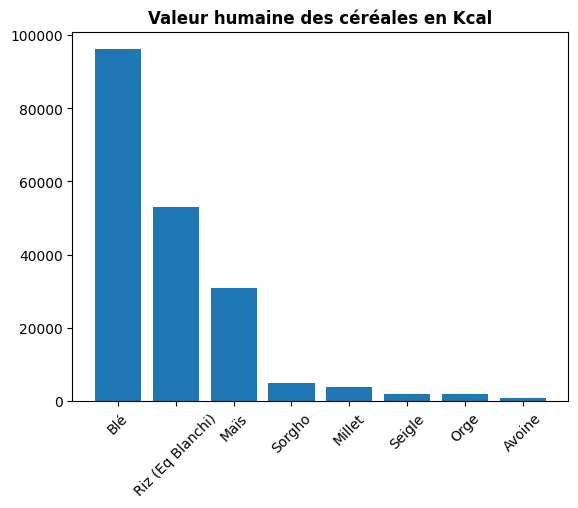

In [186]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
cereal_info = pd.DataFrame(da)
da_cereales = da[da['Produit'].isin(cereal)]
da_cereales_grouped = da_cereales.groupby('Produit')['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()
da_cereales_grouped_sorted = da_cereales_grouped.sort_values(by='Disponibilité alimentaire (Kcal/personne/jour)', ascending=False)


plt.bar(da_cereales_grouped_sorted["Produit"], da_cereales_grouped_sorted['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.title('Valeur humaine des céréales en Kcal',fontweight="bold")
plt.xticks(rotation=45)
plt.show()


In [187]:
#Affichage de la proportion d'alimentation animale

da_animal_cereal = da_cereales["Aliments pour animaux"].sum()
da_humain_cereal = da_cereales["Disponibilité alimentaire (Kcal/personne/jour)"]
da_perte_cereal = da_cereales["Pertes"].sum()
da_production_cereal = da_cereales["Production"].sum()
da_nourriture_cereal  = da_cereales["Nourriture"].sum()
da_traitement_cereal = da_cereales["Traitement"].sum()
da_semences_cereal = da_cereales["Semences"].sum()
da_autre_cereal = da_cereales["Autres Utilisations"].sum()

dispo_int_cereal  = da_animal_cereal + da_humain_cereal + da_perte_cereal + da_production_cereal + da_nourriture_cereal + da_traitement_cereal + da_semences_cereal + da_autre_cereal

prop_animal_cereal = (da_animal_cereal / dispo_int_cereal) * 100

prop_animal_cereal_pourcentage = prop_animal_cereal.sum() / len(prop_animal_cereal)


print(prop_animal_cereal_pourcentage)



17.52905685798134


In [188]:
#Affichage de la proportion d'alimentation animale


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [189]:
#Création de la colonne proportion par pays
# Création d'un tableau regroupant le Top 10 des pays en sous nutritions
sn_2017 = sn[sn['Année'].apply(lambda x: contains_année(x, 2018))]
pop_2017["Population_multiple"] = pd.to_numeric(pop_2017["Population_multiple"], errors="coerce")
print(sn_2017)
sn_2017["Sous_nutri_multiple"] = pd.to_numeric(sn_2017["Sous_nutri_multiple"], errors="coerce")

total_pop_pays = pop_2017.groupby(["Zone"])["Population_multiple"].sum()
total_sous_noutri_pays = sn_2017.groupby(["Zone"])["Sous_nutri_multiple"].sum() * 1000000
total_Pourcentage_Sous_Noutri = (total_sous_noutri_pays / total_pop_pays) * 100

tableau = pd.DataFrame({
    "Total_Pop_Pays": total_pop_pays,
    "Total_Sous_Noutri_Pays": total_sous_noutri_pays,
    "Total_Pourcentage_Sous_Noutri" : total_Pourcentage_Sous_Noutri
}).fillna(0) 

# Supprime toutes les valeurs infini car 0 % de sous nutrition
tableau.replace([np.inf, -np.inf], 0, inplace=True)


# Prend les 10 meilleurs valeurs 
top10 = tableau.sort_values(by="Total_Pourcentage_Sous_Noutri", ascending=False).head(10)
print(top10)


                                        Zone      Année  sous_nutrition  \
5                                Afghanistan  2017-2019            11.1   
11                            Afrique du Sud  2017-2019             3.3   
17                                   Albanie  2017-2019             0.1   
23                                   Algérie  2017-2019             1.2   
29                                 Allemagne  2017-2019             0.0   
...                                      ...        ...             ...   
1193  Venezuela (République bolivarienne du)  2017-2019             9.1   
1199                                Viet Nam  2017-2019             6.1   
1205                                   Yémen  2017-2019             0.0   
1211                                  Zambie  2017-2019             0.0   
1217                                Zimbabwe  2017-2019             0.0   

      Sous_nutri_multiple  
5              11100000.0  
11              3300000.0  
17             

C:\Users\User\AppData\Local\Temp\ipykernel_31580\2318484549.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_2017["Population_multiple"] = pd.to_numeric(pop_2017["Population_multiple"], errors="coerce")
C:\Users\User\AppData\Local\Temp\ipykernel_31580\2318484549.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sn_2017["Sous_nutri_multiple"] = pd.to_numeric(sn_2017["Sous_nutri_multiple"], errors="coerce")


                                        Total_Pop_Pays  \
Zone                                                     
Haïti                                       10982366.0   
Madagascar                                  25570512.0   
Tchad                                       15016753.0   
Libéria                                      4702226.0   
Rwanda                                      11980961.0   
Mozambique                                  28649018.0   
Lesotho                                      2091534.0   
Timor-Leste                                  1243258.0   
Venezuela (République bolivarienne du)      29402484.0   
Afghanistan                                 36296113.0   

                                        Total_Sous_Noutri_Pays  \
Zone                                                             
Haïti                                             5.400000e+12   
Madagascar                                        1.100000e+13   
Tchad                                  

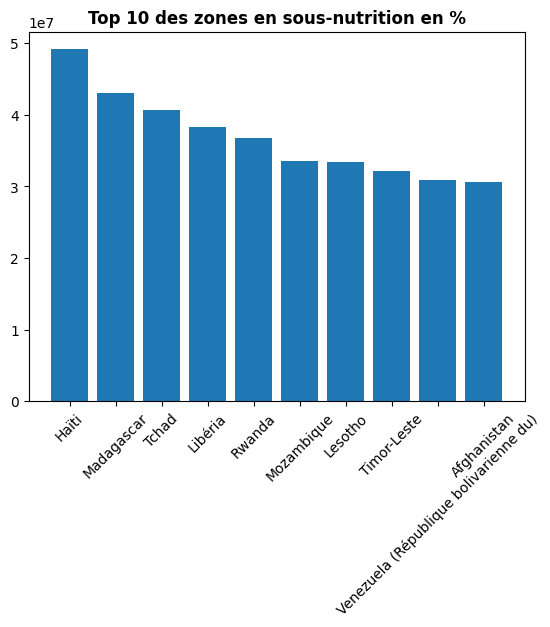

In [190]:
#affichage après trie des 10 pires pays

print(top10)
# Création du graphique 
plt.bar(top10.index, top10['Total_Pourcentage_Sous_Noutri'])
plt.title('Top 10 des zones en sous-nutrition en %',fontweight="bold")
plt.xticks(rotation=45)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [191]:
#calcul du total de l'aide alimentaire par pays
aide_ali_pays = al.groupby("Zone")["Valeur"].sum()
print(aide_ali_pays)

Zone
Afghanistan     185452
Algérie          81114
Angola            5014
Bangladesh      348188
Bhoutan           2666
                ...   
Zambie            3026
Zimbabwe         62570
Égypte            1122
Équateur          1362
Éthiopie       1381294
Name: Valeur, Length: 75, dtype: int64


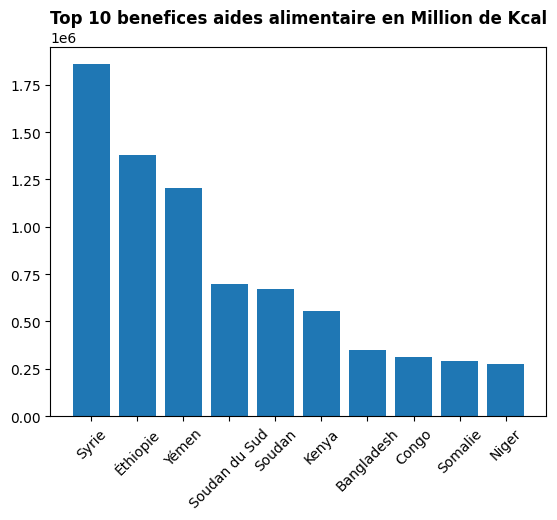

             Zone   Valeur
62          Syrie  1858943
74       Éthiopie  1381294
69          Yémen  1206484
59  Soudan du Sud   695248
58         Soudan   669784
32          Kenya   552836
3      Bangladesh   348188
15          Congo   311452
57        Somalie   292678
45          Niger   276344


In [192]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
aide_ali_pays = al.groupby("Zone", as_index=False)["Valeur"].sum()
top10_aide_ali = aide_ali_pays.sort_values(by="Valeur", ascending=False).head(10)

plt.bar(top10_aide_ali['Zone'], top10_aide_ali['Valeur'])
plt.title('Top 10 benefices aides alimentaire en Million de Kcal', fontweight="bold")
plt.xticks(rotation=45)
plt.show()
print(top10_aide_ali)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [193]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
tableau_al_zone_annee = {
    'zone': al["Zone"],
    'année': al["Année"],
    'aide_alimentaire': al["Valeur"],
}


al_zone_annee = pd.DataFrame(tableau_al_zone_annee)

print(al_zone_annee)

             zone  année  aide_alimentaire
0     Afghanistan   2013               682
1     Afghanistan   2014               335
2     Afghanistan   2013             39224
3     Afghanistan   2014             15160
4     Afghanistan   2013             40504
...           ...    ...               ...
1470     Zimbabwe   2015                96
1471     Zimbabwe   2013              5022
1472     Zimbabwe   2014              2310
1473     Zimbabwe   2015               306
1474     Zimbabwe   2013                64

[1475 rows x 3 columns]


In [194]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
al_zone_annee_groupby = al_zone_annee.groupby("zone", as_index=False)["aide_alimentaire"].sum()
top5_aide = al_zone_annee_groupby.sort_values(by="aide_alimentaire", ascending=False).head(5)

print(top5_aide)

             zone  aide_alimentaire
62          Syrie           1858943
74       Éthiopie           1381294
69          Yémen           1206484
59  Soudan du Sud            695248
58         Soudan            669784


In [195]:
#On filtre sur le dataframe avec notre liste


In [196]:
# Affichage des pays avec l'aide alimentaire par année
al_groupby_zone_annee = al_zone_annee.groupby(['zone', 'année'])['aide_alimentaire'].sum().reset_index()

print("\n✅ Résultat après groupby (une seule ligne par année) :")
print(al_groupby_zone_annee)


✅ Résultat après groupby (une seule ligne par année) :
            zone  année  aide_alimentaire
0    Afghanistan   2013            128238
1    Afghanistan   2014             57214
2        Algérie   2013             35234
3        Algérie   2014             18980
4        Algérie   2015             17424
..           ...    ...               ...
220       Égypte   2013              1122
221     Équateur   2013              1362
222     Éthiopie   2013            591404
223     Éthiopie   2014            586624
224     Éthiopie   2015            203266

[225 rows x 3 columns]


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [197]:
#Calcul de la disponibilité en kcal par personne par jour par pays
da_groupby_zone_annee = da.groupby(['Zone'])['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index()

print("\n✅ Résultat après groupby (une seule ligne par année) :")
print(da_groupby_zone_annee)


✅ Résultat après groupby (une seule ligne par année) :
                    Zone  Disponibilité alimentaire (Kcal/personne/jour)
0            Afghanistan                                          2087.0
1         Afrique du Sud                                          3020.0
2                Albanie                                          3188.0
3                Algérie                                          3293.0
4              Allemagne                                          3503.0
..                   ...                                             ...
169               Égypte                                          3518.0
170  Émirats arabes unis                                          3275.0
171             Équateur                                          2346.0
172             Éthiopie                                          2129.0
173         Îles Salomon                                          2383.0

[174 rows x 2 columns]


           Zone  Disponibilité alimentaire (Kcal/personne/jour)
12     Autriche                                          3770.0
17     Belgique                                          3737.0
160     Turquie                                          3708.0
5      Amérique                                          3682.0
77       Israël                                          3610.0
75      Irlande                                          3602.0
78       Italie                                          3578.0
92   Luxembourg                                          3540.0
169      Égypte                                          3518.0
4     Allemagne                                          3503.0


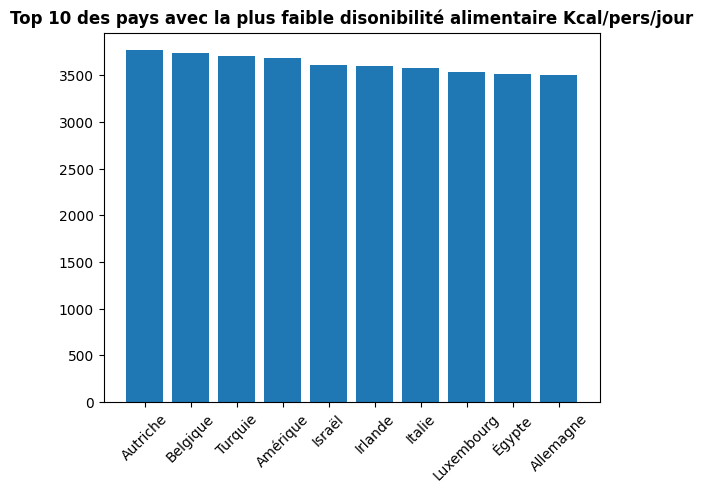

In [198]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
top10_pays_da_faible = da_groupby_zone_annee.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False).head(10)

print(top10_pays_da_faible)


plt.bar(top10_pays_da_faible['Zone'], top10_pays_da_faible['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.title('Top 10 des pays avec la plus faible disonibilité alimentaire Kcal/pers/jour',fontweight="bold")
plt.xticks(rotation=45)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

           Zone  Disponibilité alimentaire (Kcal/personne/jour)
12     Autriche                                          3770.0
17     Belgique                                          3737.0
160     Turquie                                          3708.0
5      Amérique                                          3682.0
77       Israël                                          3610.0
75      Irlande                                          3602.0
78       Italie                                          3578.0
92   Luxembourg                                          3540.0
169      Égypte                                          3518.0
4     Allemagne                                          3503.0


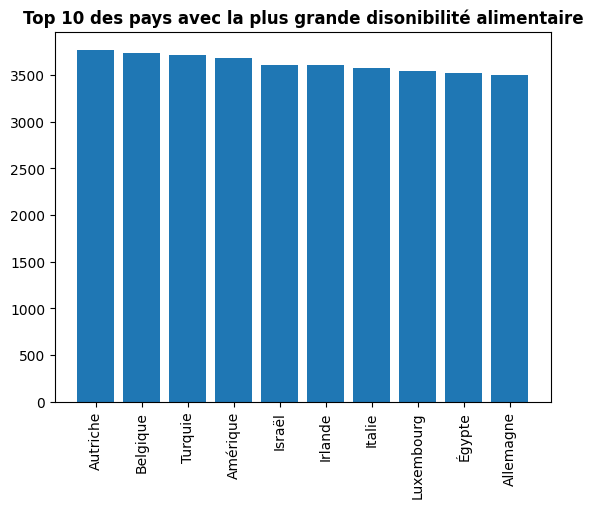

In [199]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
top10_pays_da_elevee = da_groupby_zone_annee.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False).head(10)

print(top10_pays_da_elevee)


plt.bar(top10_pays_da_elevee['Zone'], top10_pays_da_elevee ['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.title('Top 10 des pays avec la plus grande disonibilité alimentaire', fontweight="bold")

plt.xticks(rotation=90)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [200]:
#création d'un dataframe avec uniquement la Thaïlande 
da_thailande = da[da["Zone"] == 'Thaïlande']

print(da_thailande)

            Zone                 Produit   Origine  Aliments pour animaux  \
13759  Thaïlande        Abats Comestible   animale                    0.0   
13760  Thaïlande         Agrumes, Autres  vegetale                    0.0   
13761  Thaïlande  Alcool, non Comestible  vegetale                    0.0   
13762  Thaïlande   Aliments pour enfants  vegetale                    0.0   
13763  Thaïlande                  Ananas  vegetale                    0.0   
...          ...                     ...       ...                    ...   
13849  Thaïlande        Viande de Suides   animale                    0.0   
13850  Thaïlande     Viande de Volailles   animale                    0.0   
13851  Thaïlande           Viande, Autre   animale                    0.0   
13852  Thaïlande                     Vin  vegetale                    0.0   
13853  Thaïlande          Épices, Autres  vegetale                    0.0   

       Autres Utilisations  Disponibilité alimentaire (Kcal/personne/jour) 

In [225]:
#Calcul de la sous nutrition en Thaïlande
da_thailande_sn = pd.merge(da_thailande, sn_2017, on="Zone", how="inner")
da_thailande_sn_pop = pd.merge(da_thailande_sn, pop_2017, on="Zone", how="inner")
da_thailande_sn_pop["Sous_nutri_multiple"] = pd.to_numeric(
    da_thailande_sn_pop["Sous_nutri_multiple"], errors="coerce"
)
da_thailande_sn_pop["Population_multiple"] = pd.to_numeric(
    da_thailande_sn_pop["Population_multiple"], errors="coerce"
)


thailande_sn = (da_thailande_sn_pop["Sous_nutri_multiple"].sum() / da_thailande_sn_pop["Population_multiple"].sum()) * 100


# Valeurs
pourcentage = thailande_sn
labels = ["Thaïlande"]
values = [pourcentage]

print(pourcentage)

9.391732183631193


In [ ]:
# On calcule la proportion exportée en fonction de la proportion
da_thailande_manioc = da_thailande[da_thailande["Produit"] == "Manioc"]

da_thailande_pro = da_thailande_manioc["Production"]
da_thailande_exp = da_thailande_manioc["Exportations - Quantité"]

da_thailande_pro_sum = da_thailande_pro.sum()
da_thailande_exp_sum = da_thailande_exp.sum()

print(da_thailande_exp_sum, da_thailande_pro_sum)
da_thailande_manioc_prop = (da_thailande_pro_sum / da_thailande_exp_sum ) * 100
print(da_thailande_manioc_prop)



da_thailande_humain = da_thailande["Disponibilité alimentaire (Kcal/personne/jour)"].sum()



print(da_thailande_humain)

print(da_thailande["Disponibilité alimentaire (Kcal/personne/jour)"].sum())
values = [da_thailande_pro_sum, da_thailande_exp_sum]
categories = ["Manioc exporté", "Manioc Produit"]
plt.figure(figsize=(6,5))
plt.bar(categories, values, color=["skyblue", "salmon"])
plt.title("Manioc exporté vs Manioc produit en Kcal", fontweight='bold')
plt.ylabel("Nombre de personnes en Millards")
plt.tight_layout()



25214.0 30228.0
119.885777742524


TypeError: unsupported operand type(s) for -: 'method' and 'tuple'

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

    Année           Zone  Valeur
0    2013         Soudan  330230
5    2014         Soudan  321904
10   2015         Soudan   17650
1    2013  Soudan du Sud  196330
6    2014  Soudan du Sud  450610
11   2015  Soudan du Sud   48308
2    2013          Syrie  563566
7    2014          Syrie  651870
12   2015          Syrie  524949
15   2016          Syrie  118558


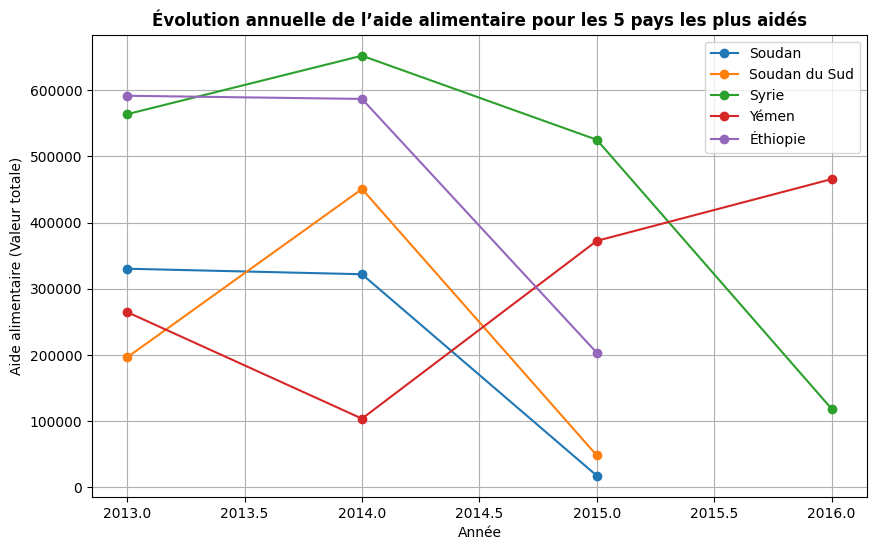

In [212]:
#ajouter en dessous toutes les analyses complémtaires

aide_ali_pays = al.groupby("Zone", as_index=False)["Valeur"].sum()
top5 = aide_ali_pays.sort_values(by="Valeur", ascending=False).head(5)

aide_top5 = al[al["Zone"].isin(top5["Zone"])]

aide_top5_annee = aide_top5.groupby(["Année", "Zone"], as_index=False)["Valeur"].sum()
aide_top5_annee.sort_values(["Zone", "Année"], inplace=True)
print(aide_top5_annee.head(10))

plt.figure(figsize=(10,6))
for pays in aide_top5_annee["Zone"].unique():
    point = aide_top5_annee[aide_top5_annee["Zone"] == pays]
    plt.plot(point["Année"], point["Valeur"], marker="o", label=pays)
    
plt.title("Évolution annuelle de l’aide alimentaire pour les 5 pays les plus aidés", fontweight='bold')
plt.xlabel("Année")
plt.ylabel("Aide alimentaire (Valeur totale)")
plt.legend()
plt.grid(True)
plt.show()
